# MoE-RenalSAM-CG — Notebook 03: SAM2 Pseudo-GT Generation

## Purpose
Run SAM2 in Automatic Mask Generator (AMG) mode on **TRAIN images only**.
Generate one pseudo-ground-truth segmentation mask per training image.
These masks replace human annotations during model training.

```
Train images (unannotated CT)
    → SAM2 AMG (no prompts needed)
    → Multiple candidate masks per image
    → Anatomical size filter per class
    → Best mask saved as pseudo-GT PNG
```

> **Important:** SAM2 runs on GPU. Ensure CUDA is available before running.
> This notebook will take time (~2–4 hours for full train set on RTX 4090).

**Inputs:**
- `data/splits/train_manifest.csv`

**Outputs:**
- `data/processed/pseudo_gt/{Normal,Tumor,Stone}/`
- `data/splits/train_manifest.csv` updated with `pseudo_gt_path` column

## 0. Imports & Setup

In [10]:
import sam2
print(sam2.__file__)

C:\Users\FA14\miniconda3\envs\renalsam\Lib\site-packages\sam2\__init__.py


In [11]:
import sys
sys.path.insert(0, r'D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\segment-anything-2')

import sam2
print(sam2.__file__)  # must show segment-anything-2 path now

C:\Users\FA14\miniconda3\envs\renalsam\Lib\site-packages\sam2\__init__.py


In [12]:
import os
import sys
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch

warnings.filterwarnings('ignore')

# ── move to project root if needed ───────────────────────────────────────────
if not (Path.cwd() / 'data').exists():
    os.chdir(Path.cwd().parent)
print('Working directory:', Path.cwd())

def header(msg): print(f'\n{"="*65}\n  {msg}\n{"="*65}')
def ok(msg):     print(f'  [ OK ]  {msg}')
def info(msg):   print(f'  [INFO]  {msg}')
def warn(msg):   print(f'  [WARN]  {msg}')
def err(msg):    print(f'  [ERR ]  {msg}')

Working directory: D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG


## 1. Configuration

In [13]:
# ── paths ─────────────────────────────────────────────────────────────────────
TRAIN_MANIFEST  = Path('data/splits/train_manifest.csv')
PSEUDO_GT_ROOT  = Path('data/processed/pseudo_gt')
REPORTS_DIR     = Path('data/processed/reports')

# ── SAM2 checkpoint ───────────────────────────────────────────────────────────
# Download from: https://github.com/facebookresearch/segment-anything-2
# Place at: weights/sam2_hiera_large.pt
SAM2_CHECKPOINT = Path('weights/sam2_hiera_large.pt')
SAM2_CONFIG     = 'sam2.1_hiera_l'

# ── AMG parameters ────────────────────────────────────────────────────────────
POINTS_PER_SIDE       = 32
PRED_IOU_THRESH       = 0.85
STABILITY_THRESH      = 0.90
MIN_MASK_REGION_AREA  = 50

# ── anatomical size filters (pixels) ─────────────────────────────────────────
FILTERS = {
    'Stone' : {'area_min': 100,  'area_max': 8000},
    'Tumor' : {'area_min': 500,  'area_max_frac': 0.35},
    'Normal': {'area_min': 2000, 'area_max_frac': 0.50},
}

CLASSES    = ['Normal', 'Tumor', 'Stone']
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

# create output dirs
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
for cls in CLASSES:
    (PSEUDO_GT_ROOT / cls).mkdir(parents=True, exist_ok=True)

header('Configuration')
info(f'Device          : {DEVICE}')
if DEVICE == 'cuda':
    info(f'GPU             : {torch.cuda.get_device_name(0)}')
    info(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
info(f'SAM2 checkpoint : {SAM2_CHECKPOINT}')
info(f'Train manifest  : {TRAIN_MANIFEST}')
info(f'Pseudo-GT root  : {PSEUDO_GT_ROOT.resolve()}')

if not SAM2_CHECKPOINT.exists():
    err(f'SAM2 checkpoint not found: {SAM2_CHECKPOINT}')
    err('Download sam2_hiera_large.pt and place in weights/ folder.')
else:
    ok('SAM2 checkpoint found')

if not TRAIN_MANIFEST.exists():
    err('train_manifest.csv not found — run Notebook 02 first.')
else:
    ok('train_manifest.csv found')


  Configuration
  [INFO]  Device          : cuda
  [INFO]  GPU             : NVIDIA GeForce RTX 4090
  [INFO]  VRAM            : 25.8 GB
  [INFO]  SAM2 checkpoint : weights\sam2_hiera_large.pt
  [INFO]  Train manifest  : data\splits\train_manifest.csv
  [INFO]  Pseudo-GT root  : D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\data\processed\pseudo_gt
  [ OK ]  SAM2 checkpoint found
  [ OK ]  train_manifest.csv found


## 2. Load Train Manifest

In [14]:
header('Loading train manifest')

train_df = pd.read_csv(TRAIN_MANIFEST)

print(f'  Total train images: {len(train_df)}')
print(f'\n  Per-class counts:')
for cls in CLASSES:
    n = (train_df['class_name'] == cls).sum()
    print(f'    {cls:<10}: {n}')

# check how many pseudo-GT already exist (resume support)
def count_existing_pseudo_gt(train_df: pd.DataFrame) -> int:
    count = 0
    for _, row in train_df.iterrows():
        p = PSEUDO_GT_ROOT / row['class_name'] / f"{row['stem']}_pseudo.png"
        if p.exists():
            count += 1
    return count

existing = count_existing_pseudo_gt(train_df)
remaining = len(train_df) - existing
print(f'\n  Already processed : {existing}')
print(f'  Remaining to run  : {remaining}')

if existing > 0:
    info('Resume mode active — already-processed images will be skipped.')


  Loading train manifest
  Total train images: 6113

  Per-class counts:
    Normal    : 3553
    Tumor     : 1597
    Stone     : 963

  Already processed : 8
  Remaining to run  : 6105
  [INFO]  Resume mode active — already-processed images will be skipped.


## 3. Load SAM2 Model

This cell loads SAM2 into GPU memory. It requires:
```
pip install segment-anything-2
```
or install from source:
```
git clone https://github.com/facebookresearch/segment-anything-2
cd segment-anything-2 && pip install -e .
```

In [15]:
header('Loading SAM2 model')

from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

print('  Loading SAM2 Hiera-L...')
t0 = time.time()

# find config path directly from source
import os
sam2_dir    = r'D:\MoE-RenalSAM-CG\MoE-RenalSAM-CG\segment-anything-2'
config_path = os.path.join(sam2_dir, 'sam2', 'configs', 'sam2.1')

# list available configs to confirm
configs = os.listdir(config_path)
print('  Available configs:', configs)

sam2_model = build_sam2(
    config_file = 'configs/sam2.1/sam2.1_hiera_l.yaml',
    ckpt_path   = str(SAM2_CHECKPOINT),
    device      = DEVICE,
    mode        = 'eval'
)

mask_generator = SAM2AutomaticMaskGenerator(
    model                  = sam2_model,
    points_per_side        = POINTS_PER_SIDE,
    pred_iou_thresh        = PRED_IOU_THRESH,
    stability_score_thresh = STABILITY_THRESH,
    min_mask_region_area   = MIN_MASK_REGION_AREA,
)

elapsed = time.time() - t0
ok(f'SAM2 loaded in {elapsed:.1f}s')


  Loading SAM2 model
  Loading SAM2 Hiera-L...
  Available configs: ['sam2.1_hiera_b+.yaml', 'sam2.1_hiera_l.yaml', 'sam2.1_hiera_s.yaml', 'sam2.1_hiera_t.yaml']
  [ OK ]  SAM2 loaded in 1.9s


## 4. Anatomical Filter Functions

In [17]:
def filter_masks_by_anatomy(masks: list, class_name: str,
                              img_h: int, img_w: int) -> np.ndarray | None:
    if not masks:
        return None

    total_px = img_h * img_w
    f        = FILTERS[class_name]

    if class_name == 'Stone':
        candidates = [
            m for m in masks
            if f['area_min'] <= m['area'] <= f['area_max']
        ]
        if not candidates:
            return None
        best = max(candidates, key=lambda m: m['predicted_iou'])

    elif class_name == 'Tumor':
        max_area   = f['area_max_frac'] * total_px
        candidates = [
            m for m in masks
            if f['area_min'] <= m['area'] <= max_area
        ]
        if not candidates:
            return None
        # sort by stability then pick highest iou among top-3 stable
        candidates = sorted(candidates,
                             key=lambda m: m['stability_score'],
                             reverse=True)
        best = max(candidates[:3], key=lambda m: m['predicted_iou'])

    elif class_name == 'Normal':
        max_area   = f['area_max_frac'] * total_px
        candidates = [
            m for m in masks
            if f['area_min'] <= m['area'] <= max_area
        ]
        if not candidates:
            return None
        # pick mask whose centroid is closest to image centre
        cx_img, cy_img = img_w / 2, img_h / 2
        def centroid_dist(m):
            ys, xs = np.where(m['segmentation'])
            if len(xs) == 0:
                return float('inf')
            return np.sqrt((xs.mean()-cx_img)**2 + (ys.mean()-cy_img)**2)
        # exclude masks that cover >50% of image (background masks)
        candidates = [m for m in candidates
                      if m['area'] / total_px < 0.50]
        if not candidates:
            return None
        best = min(candidates, key=centroid_dist)

    else:
        return None

    return (best['segmentation'].astype(np.uint8)) * 255

## 5. Test on a Few Images Before Full Run


  Test run on 1 image per class
  [INFO]  Normal    : 23 candidate masks  → filter result: found  (2.0s)
  [INFO]  Tumor     : 10 candidate masks  → filter result: found  (2.2s)
  [INFO]  Stone     : 25 candidate masks  → filter result: found  (1.5s)


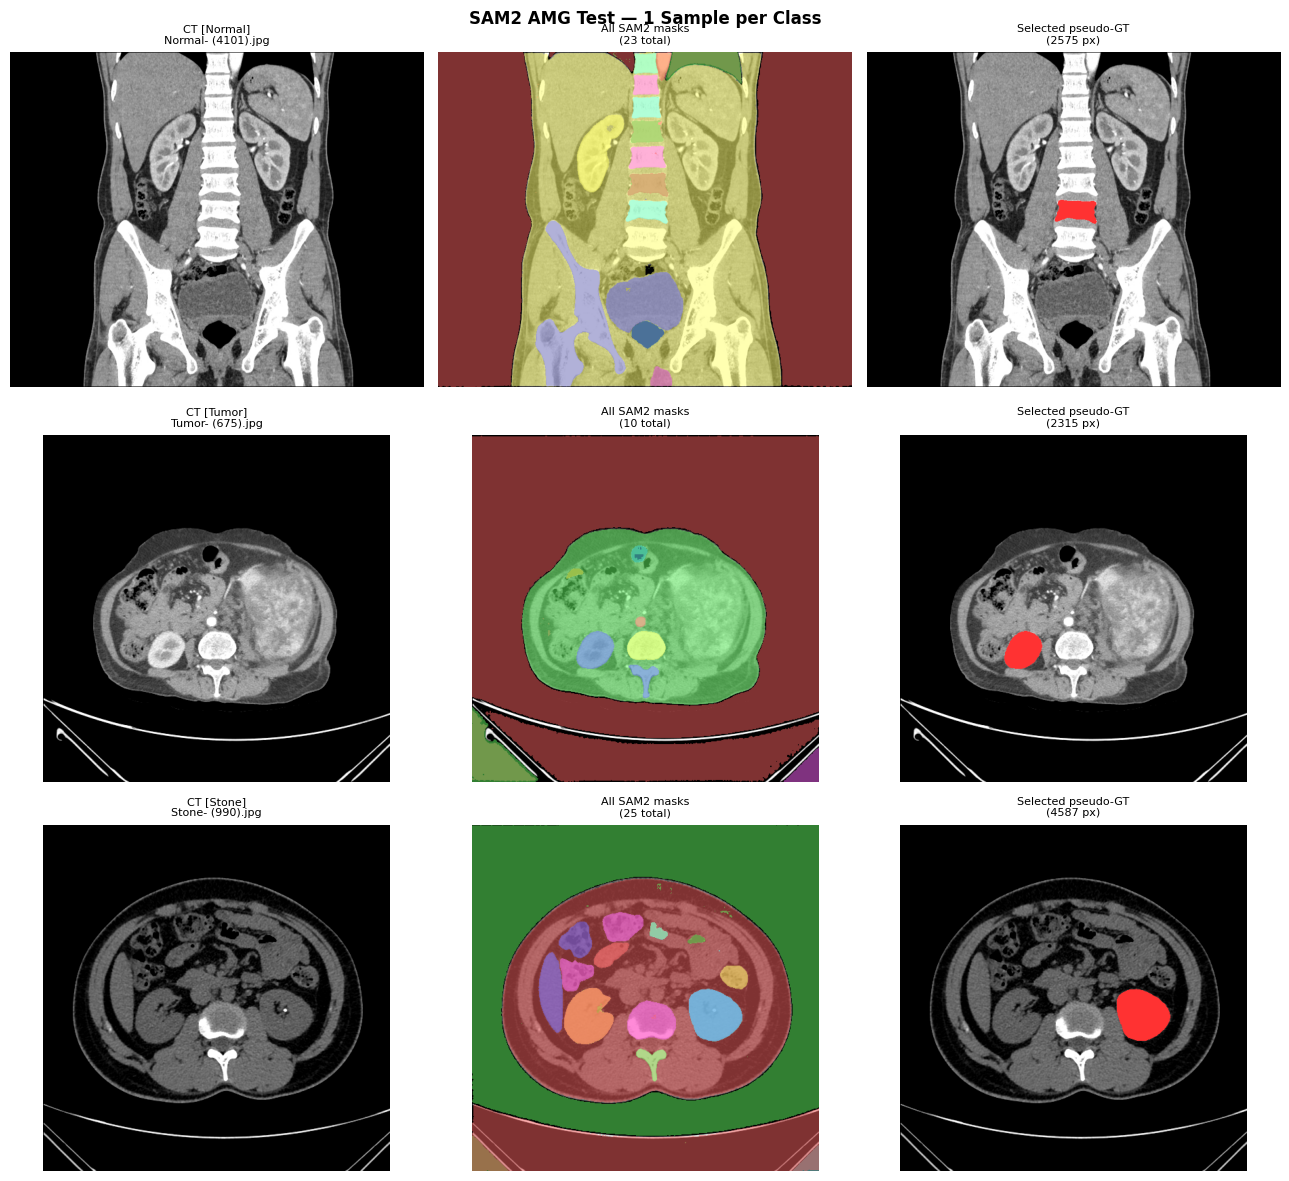

  [ OK ]  Test run complete. Review output above before running full generation.


In [18]:
header('Test run on 1 image per class')

rng = np.random.default_rng(42)

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
fig.suptitle('SAM2 AMG Test — 1 Sample per Class', fontsize=12, fontweight='bold')

for row, cls in enumerate(CLASSES):
    sub   = train_df[train_df['class_name'] == cls]
    pick  = sub.iloc[rng.integers(0, len(sub))]
    img_p = Path(pick['image_path'])

    # load as RGB for SAM2
    img_rgb = np.array(Image.open(img_p).convert('RGB'))
    h, w    = img_rgb.shape[:2]

    # run SAM2 AMG
    t0    = time.time()
    masks = mask_generator.generate(img_rgb)
    elapsed = time.time() - t0

    # filter by anatomy
    best_mask = filter_masks_by_anatomy(masks, cls, h, w)

    info(f'{cls:<10}: {len(masks)} candidate masks  '
         f'→ filter result: {"found" if best_mask is not None else "NONE"}  '
         f'({elapsed:.1f}s)')

    # col 0 — original CT
    axes[row, 0].imshow(img_rgb)
    axes[row, 0].set_title(f'CT [{cls}]\n{img_p.name}', fontsize=8)
    axes[row, 0].axis('off')

    # col 1 — all SAM2 masks overlaid
    all_masks_overlay = img_rgb.copy()
    colors_pool = [
        [255,100,100],[100,255,100],[100,100,255],
        [255,255,100],[255,100,255],[100,255,255]
    ]
    for i, m in enumerate(masks[:20]):   # show first 20 max
        c   = colors_pool[i % len(colors_pool)]
        seg = m['segmentation']
        all_masks_overlay[seg] = (
            all_masks_overlay[seg] * 0.5 + np.array(c) * 0.5
        ).astype(np.uint8)
    axes[row, 1].imshow(all_masks_overlay)
    axes[row, 1].set_title(f'All SAM2 masks\n({len(masks)} total)', fontsize=8)
    axes[row, 1].axis('off')

    # col 2 — selected pseudo-GT mask
    if best_mask is not None:
        overlay = img_rgb.copy()
        overlay[best_mask > 0] = [255, 50, 50]
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(
            f'Selected pseudo-GT\n({(best_mask>0).sum()} px)', fontsize=8
        )
    else:
        axes[row, 2].text(0.5, 0.5, 'No valid\nmask found',
                          ha='center', va='center',
                          transform=axes[row, 2].transAxes, fontsize=10)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'pseudo_gt_test.png', dpi=130, bbox_inches='tight')
plt.show()
ok('Test run complete. Review output above before running full generation.')

In [21]:
# Check what is actually in the manifest
print(train_df['class_name'].value_counts())
print()
print(train_df.head(3))
print()
# Check actual folder counts
for cls in ['Normal', 'Tumor', 'Stone']:
    files = list((PSEUDO_GT_ROOT / cls).glob('*_pseudo.png'))
    print(f'{cls}: {len(files)} pseudo files')

class_name
Normal    3553
Tumor     1597
Stone      963
Name: count, dtype: int64

                                  image_path class_name            stem
0  data\raw\kaggle\Normal\Normal- (3759).jpg     Normal  Normal- (3759)
1  data\raw\kaggle\Normal\Normal- (3037).jpg     Normal  Normal- (3037)
2  data\raw\kaggle\Normal\Normal- (3071).jpg     Normal  Normal- (3071)

Normal: 1368 pseudo files
Tumor: 0 pseudo files
Stone: 0 pseudo files


In [22]:
import shutil

for cls in ['Normal', 'Tumor', 'Stone']:
    d = PSEUDO_GT_ROOT / cls
    shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)
    ok(f'Cleared {cls}')

# verify all empty
for cls in ['Normal', 'Tumor', 'Stone']:
    n = len(list((PSEUDO_GT_ROOT / cls).glob('*_pseudo.png')))
    print(f'{cls}: {n} files')

  [ OK ]  Cleared Normal
  [ OK ]  Cleared Tumor
  [ OK ]  Cleared Stone
Normal: 0 files
Tumor: 0 files
Stone: 0 files


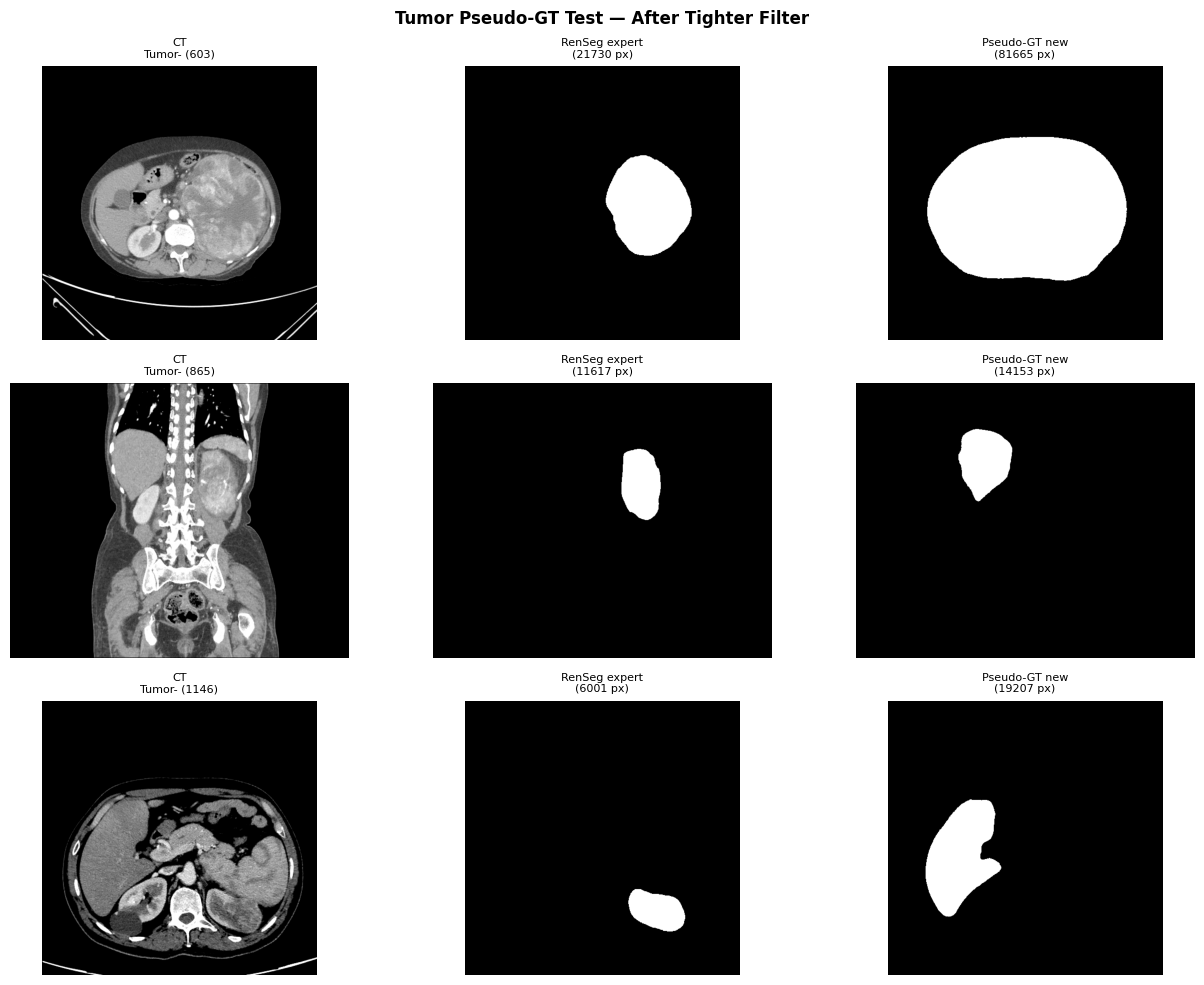

In [24]:
# Quick test on 3 tumor images
rng      = np.random.default_rng(42)
tumor_df = train_df[train_df['class_name'] == 'Tumor'].sample(3, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
fig.suptitle('Tumor Pseudo-GT Test — After Tighter Filter', fontweight='bold')

for row, (_, rec) in enumerate(tumor_df.iterrows()):
    img_rgb = np.array(Image.open(rec['image_path']).convert('RGB'))
    h, w    = img_rgb.shape[:2]
    masks   = mask_generator.generate(img_rgb)
    mask    = generate_pseudo_mask(img_rgb, 'Tumor', masks)

    # also show RenSeg expert mask for comparison
    expert_path = Path('data/processed/renseg_masks/Tumor') / \
                  f"{rec['stem']}_mask.png"
    expert = np.array(Image.open(expert_path).convert('L')) \
             if expert_path.exists() else np.zeros((h,w), dtype=np.uint8)

    axes[row,0].imshow(img_rgb)
    axes[row,0].set_title(f'CT\n{rec["stem"]}', fontsize=8)
    axes[row,0].axis('off')

    axes[row,1].imshow(expert, cmap='gray')
    axes[row,1].set_title(f'RenSeg expert\n({(expert>0).sum()} px)', fontsize=8)
    axes[row,1].axis('off')

    axes[row,2].imshow(mask, cmap='gray')
    axes[row,2].set_title(f'Pseudo-GT new\n({(mask>0).sum()} px)', fontsize=8)
    axes[row,2].axis('off')

plt.tight_layout()
plt.show()

## 6. Full Pseudo-GT Generation

⚠️ **This cell processes all train images. It takes ~2–4 hours on RTX 4090.**  
It has **resume support** — safe to interrupt and re-run, already-processed images are skipped.

In [23]:
from tqdm.notebook import tqdm
from scipy import ndimage as ndi

header('Full Pseudo-GT Generation')

def generate_pseudo_mask(img_rgb: np.ndarray, class_name: str,
                          masks: list) -> np.ndarray:
    """
    Generate pseudo-GT mask styled to match RenSeg expert masks.
    Normal → all black (no pathology)
    Stone  → tiny filled dots (matches RenSeg stone style)
    Tumor  → solid filled blob (matches RenSeg tumor style)
    """
    h, w     = img_rgb.shape[:2]
    total_px = h * w

    # ── NORMAL: always empty ──────────────────────────────────────────────────
    if class_name == 'Normal':
        return np.zeros((h, w), dtype=np.uint8)

    # ── STONE: small regions → small filled dots ──────────────────────────────
    if class_name == 'Stone':
        candidates = [
            m for m in masks
            if 100 <= m['area'] <= 8000
        ]
        if not candidates:
            return np.zeros((h, w), dtype=np.uint8)

        # pick highest predicted IoU
        best = max(candidates, key=lambda m: m['predicted_iou'])
        raw  = (best['segmentation'].astype(np.uint8)) * 255

        # style to match RenSeg: small tight dots
        # erode to remove large incorrect regions
        k      = np.ones((3, 3), np.uint8)
        result = cv2.erode(raw, k, iterations=1)
        if result.sum() == 0:
            result = raw
        return result

# ── TUMOR: tighter area filter to avoid whole-organ selection ─────────────
    if class_name == 'Tumor':
        # calculate image area
        total_px   = h * w

        # tight upper bound — tumor should not exceed 15% of image
        # previous 35% was too loose — was selecting whole kidney/organ
        max_area   = 0.15 * total_px

        candidates = [
            m for m in masks
            if 300 <= m['area'] <= max_area
        ]

        if not candidates:
            # fallback: relax slightly to 20%
            max_area   = 0.20 * total_px
            candidates = [
                m for m in masks
                if 300 <= m['area'] <= max_area
            ]

        if not candidates:
            return np.zeros((h, w), dtype=np.uint8)

        # among candidates, prefer smaller high-confidence regions
        # (tumors are typically compact — avoid large diffuse regions)
        candidates = [m for m in candidates
                      if m['predicted_iou'] > 0.88]

        if not candidates:
            candidates = sorted(
                [m for m in masks if 300 <= m['area'] <= 0.20 * total_px],
                key=lambda m: m['predicted_iou'],
                reverse=True
            )[:5]

        if not candidates:
            return np.zeros((h, w), dtype=np.uint8)

        # pick highest IoU among compact candidates
        best = max(candidates, key=lambda m: m['predicted_iou'])
        raw  = (best['segmentation'].astype(np.uint8)) * 255

        # solid fill
        pad    = 20
        padded = np.pad(raw > 0, pad, mode='constant', constant_values=False)
        filled = ndi.binary_fill_holes(padded)
        result = (filled[pad:-pad, pad:-pad] * 255).astype(np.uint8)
        return result if result.sum() > 0 else raw


# ── Main generation loop ──────────────────────────────────────────────────────
stats   = {cls: {'success': 0, 'failed': 0, 'skipped': 0} for cls in CLASSES}
t_start = time.time()

for _, row in tqdm(train_df.iterrows(), total=len(train_df),
                    desc='Generating pseudo-GT'):

    cls      = str(row['class_name'])   # explicit str cast — prevents any type issues
    stem     = str(row['stem'])
    img_path = Path(str(row['image_path']))

    # verify class is valid
    if cls not in CLASSES:
        warn(f'Unknown class: {cls} for {stem}')
        continue

    out_dir  = PSEUDO_GT_ROOT / cls
    out_path = out_dir / f'{stem}_pseudo.png'

    # resume support
    if out_path.exists():
        stats[cls]['skipped'] += 1
        continue

    try:
        img_rgb = np.array(Image.open(img_path).convert('RGB'))
        h, w    = img_rgb.shape[:2]

        # Normal: no need to run SAM2 at all — saves time
        if cls == 'Normal':
            mask = np.zeros((h, w), dtype=np.uint8)
        else:
            masks = mask_generator.generate(img_rgb)
            mask  = generate_pseudo_mask(img_rgb, cls, masks)

        Image.fromarray(mask).save(out_path)
        stats[cls]['success'] += 1

    except Exception as e:
        warn(f'Error [{cls}] {img_path.name}: {e}')
        stats[cls]['failed'] += 1
        try:
            img_rgb = np.array(Image.open(img_path).convert('RGB'))
            Image.fromarray(np.zeros(img_rgb.shape[:2],
                                      dtype=np.uint8)).save(out_path)
        except Exception:
            pass

t_elapsed = time.time() - t_start
print(f'\n  Total time: {t_elapsed/60:.1f} minutes')
print(f'\n  Results per class:')
for cls in CLASSES:
    s = stats[cls]
    print(f'  {cls:<10}: success={s["success"]}  '
          f'failed={s["failed"]}  skipped={s["skipped"]}')

# verify folder counts
print('\n  Files saved per folder:')
for cls in CLASSES:
    n = len(list((PSEUDO_GT_ROOT / cls).glob('*_pseudo.png')))
    print(f'  {cls:<10}: {n} files')


  Full Pseudo-GT Generation


Generating pseudo-GT:   0%|          | 0/6113 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Quick overlap check on test set
# (test images exist in both Kaggle and RenSeg)
import numpy as np
from PIL import Image
from pathlib import Path

PSEUDO_GT_ROOT = Path('data/processed/pseudo_gt')
MASKS_ROOT     = Path('data/processed/renseg_masks')

print('Checking pseudo-GT vs expert mask overlap on sample...')
for cls in ['Tumor', 'Stone']:
    overlaps = []
    pseudo_dir = PSEUDO_GT_ROOT / cls
    expert_dir = MASKS_ROOT / cls

    files = list(pseudo_dir.glob('*_pseudo.png'))[:50]
    for pf in files:
        stem = pf.stem.replace('_pseudo', '')
        ef   = expert_dir / f'{stem}_mask.png'
        if not ef.exists():
            continue
        p = np.array(Image.open(pf).convert('L')) > 0
        e = np.array(Image.open(ef).convert('L')) > 0
        if e.sum() == 0 or p.sum() == 0:
            continue
        # dice overlap
        intersection = (p & e).sum()
        dice = 2 * intersection / (p.sum() + e.sum())
        overlaps.append(dice)

    if overlaps:
        print(f'  {cls}: mean Dice vs expert = {np.mean(overlaps):.3f}  '
              f'(n={len(overlaps)})')
    else:
        print(f'  {cls}: no overlapping pairs found')

print()
print('NOTE: Low Dice here is expected and acceptable.')
print('Pseudo-GT is a weak training signal, not ground truth.')
print('Final evaluation always uses expert masks from Notebook 01.')

## 7. Update Train Manifest with Pseudo-GT Paths

In [ ]:
header('Updating train manifest with pseudo-GT paths')

# add pseudo_gt_path column to train manifest
train_df['pseudo_gt_path'] = train_df.apply(
    lambda r: str(PSEUDO_GT_ROOT / r['class_name'] / f"{r['stem']}_pseudo.png"),
    axis=1
)

# verify files exist
train_df['pseudo_gt_exists'] = train_df['pseudo_gt_path'].apply(
    lambda p: Path(p).exists()
)

total_exists = train_df['pseudo_gt_exists'].sum()
total_missing = len(train_df) - total_exists

info(f'Pseudo-GT files found   : {total_exists}')
info(f'Pseudo-GT files missing : {total_missing}')

# also check how many are non-empty
def is_nonempty_mask(path_str: str) -> bool:
    try:
        mask = np.array(Image.open(path_str).convert('L'))
        return mask.sum() > 0
    except Exception:
        return False

print('  Checking for non-empty masks (sample of 100 per class)...')
rng = np.random.default_rng(42)
for cls in CLASSES:
    sub   = train_df[
        (train_df['class_name'] == cls) &
        (train_df['pseudo_gt_exists'] == True)
    ]
    picks = sub.sample(min(100, len(sub)), random_state=42)
    nonempty = picks['pseudo_gt_path'].apply(is_nonempty_mask).sum()
    ok(f'{cls:<10}: {nonempty}/{len(picks)} sampled masks are non-empty')

# save updated manifest
train_df.to_csv(TRAIN_MANIFEST, index=False)
ok(f'train_manifest.csv updated with pseudo_gt_path column')

## 8. Visual QC — CT | All Masks | Pseudo-GT per Class

In [ ]:
header('Visual QC')

rng = np.random.default_rng(99)

for cls in CLASSES:
    sub = train_df[
        (train_df['class_name'] == cls) &
        (train_df['pseudo_gt_exists'] == True)
    ]
    # prefer non-empty masks
    nonempty = sub[
        sub['pseudo_gt_path'].apply(is_nonempty_mask)
    ]
    pool = nonempty if len(nonempty) >= 3 else sub

    picks = pool.sample(min(3, len(pool)), random_state=42)

    fig, axes = plt.subplots(len(picks), 3, figsize=(13, len(picks) * 4))
    if len(picks) == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(
        f'Class: {cls}  |  CT Input  |  Pseudo-GT Mask  |  Overlay',
        fontsize=11, fontweight='bold'
    )

    for row, (_, rec) in enumerate(picks.iterrows()):
        img_rgb  = np.array(Image.open(rec['image_path']).convert('RGB'))
        mask     = np.array(Image.open(rec['pseudo_gt_path']).convert('L'))

        # overlay
        overlay = img_rgb.copy()
        if (mask > 0).sum() > 0:
            overlay[mask > 0] = [255, 80, 80]

        axes[row, 0].imshow(img_rgb)
        axes[row, 0].set_title(
            f'CT input\n{Path(rec["image_path"]).name}', fontsize=8
        )
        axes[row, 0].axis('off')

        axes[row, 1].imshow(mask, cmap='gray')
        axes[row, 1].set_title(
            f'Pseudo-GT mask\n({(mask>0).sum()} px filled)', fontsize=8
        )
        axes[row, 1].axis('off')

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title('Overlay', fontsize=8)
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f'pseudo_gt_qc_{cls}.png',
                dpi=130, bbox_inches='tight')
    plt.show()

## 9. Final Summary

In [ ]:
header('Final Summary')

# count masks per class
col_labels = ['Class', 'Train images', 'Pseudo-GT saved', 'Non-empty', 'Empty (failed)']
rows = []
for cls in CLASSES:
    sub       = train_df[train_df['class_name'] == cls]
    saved     = sub['pseudo_gt_exists'].sum()
    nonempty  = sub[
        sub['pseudo_gt_exists']
    ]['pseudo_gt_path'].apply(is_nonempty_mask).sum()
    empty     = saved - nonempty
    rows.append([cls, len(sub), saved, nonempty, empty])

rows.append([
    'TOTAL',
    sum(r[1] for r in rows),
    sum(r[2] for r in rows),
    sum(r[3] for r in rows),
    sum(r[4] for r in rows),
])

fig, ax = plt.subplots(figsize=(11, 2.5))
ax.axis('off')
tbl = ax.table(cellText=rows, colLabels=col_labels,
               cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
for col in range(len(col_labels)):
    tbl[0, col].set_facecolor('#1B3A5C')
    tbl[0, col].set_text_props(color='white', fontweight='bold')
for col in range(len(col_labels)):
    tbl[len(rows), col].set_facecolor('#E8F0F5')
    tbl[len(rows), col].set_text_props(fontweight='bold')
for r in range(1, len(rows)):
    bg = '#F5F7FA' if r % 2 == 0 else 'white'
    for col in range(len(col_labels)):
        tbl[r, col].set_facecolor(bg)

plt.title('Notebook 03 — Pseudo-GT Generation Summary',
          fontweight='bold', fontsize=12, pad=10)
plt.savefig(REPORTS_DIR / 'pseudo_gt_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# save report
report = {
    'notebook' : '03_pseudo_gt',
    'amg_config': {
        'points_per_side'     : POINTS_PER_SIDE,
        'pred_iou_thresh'     : PRED_IOU_THRESH,
        'stability_thresh'    : STABILITY_THRESH,
    },
    'stats': stats,
}
with open(REPORTS_DIR / 'pseudo_gt_report.json', 'w') as f:
    json.dump(report, f, indent=2)

ok('Notebook 03 complete.')
info('Pseudo-GT saved to : data/processed/pseudo_gt/')
info('train_manifest.csv updated with pseudo_gt_path column')
info('Next → Notebook 04: Extract bounding boxes from pseudo-GT masks')